(02-08-capm)=

# Het CAPM

```{admonition} Waar we zijn in het verhaal
:class: important

**Jaartal.** 1961–1973.

**Wat we al weten.** In [](#01-04-markowitz) mengt elke mean-variance-belegger
de risicovrije rente met één en dezelfde tangentportefeuille: de mix van
risicovolle activa met de hoogste Sharpe-ratio. De event study van
[](#02-07-event-studies) scheidt een normaal van een abnormaal rendement met het
marktmodel. Maar dat marktmodel is een regressie zonder economische inhoud. Het
zegt niet welk verwacht rendement bij welk aandeel hoort.

**Welke vraag staat open.** Als iedereen doet wat Markowitz voorschrijft en de
markt moet ruimen, welk verwacht rendement hoort dan bij welk risico?
```

## Overzicht

Welk verwacht rendement hoort bij welk aandeel, als alle beleggers dezelfde
tangentportefeuille houden? Omdat alle beleggers samen de hele markt bezitten, is
die portefeuille de markt. Dan is het verwachte *excess rendement* (het rendement
boven de risicovrije rente) van elk aandeel evenredig met één getal: zijn bèta met de markt. In deze lecture:

- leiden we die lineaire relatie, de *security market line* (SML), af uit
  marktclearing en de efficiënte rand van Markowitz;

- laten we zien hoe het CAPM getoetst wordt: met een tijdreeksregressie per
  portefeuille en met de maandelijkse cross-sectie van Fama en MacBeth;

- simuleren we wat die toetsen vinden in een wereld waar het CAPM exact geldt,
  met geschatte in plaats van ware bèta's;

- repliceren we het centrale feit van het tijdvak, een SML die vlakker is dan
  voorspeld, in de stijl van Black, Jensen en Scholes en van Fama en MacBeth.

Tussen 1961 en 1966 schreven vier mensen los van elkaar hetzelfde model op: Jack
Treynor {cite}`Treynor1961,Treynor1962`, William Sharpe {cite}`Sharpe1964`, John
Lintner {cite}`Lintner1965` en Jan Mossin {cite}`Mossin1966`. Het *Capital Asset
Pricing Model* is de eerste evenwichtstheorie van verwachte rendementen in deze
reeks: ze zegt niet wat een belegger moet doen, maar welk rendement de markt aan
elk activum geeft. In de vraag theorie of feit die de reeks
doorloopt, is het CAPM zuiver theorie: eerst het model, dan de toets. De toetsen kwamen snel
{cite}`Jensen1968,BlackJensenScholes1972,FamaMacBeth1973`, en de eerste barst
ook: de lijn was te vlak.

## Intuïtie: waarom zou dit waar zijn?

Markowitz en Tobin lieten zien dat een belegger die alleen om verwachting en
risico geeft, zijn risicovolle geld in één mandje stopt. De voorzichtige belegger
houdt er weinig van en leent de rest uit. De agressieve leent bij en houdt er
meer dan zijn vermogen van. Het mandje zelf is voor beiden hetzelfde.

Het CAPM voegt één stap toe, en die stap is boekhouding. Als iedereen hetzelfde
mandje houdt, houden alle beleggers samen ook dat mandje. Wat alle beleggers
samen houden, is alles wat er te koop is. Het mandje moet dus de samenstelling
van de hele markt hebben. Wil iedereen meer van een aandeel dan er bestaat, dan
stijgt zijn prijs en daalt zijn verwachte rendement, tot de vraag past.

In het optimale mandje levert elk aandeel per eenheid toegevoegd risico hetzelfde
extra rendement op. Anders zou de belegger er meer of minder van kopen. Het risico
dat een aandeel toevoegt, is hoe sterk het meebeweegt met het mandje, en het
mandje is de markt. Die meebeweging, geschaald zodat de markt zelf op één uitkomt,
heet de *bèta*.

Wat verwachten we dus? Een aandeel met een hogere bèta heeft een hoger verwacht
rendement, en de relatie is een rechte lijn door de risicovrije rente en door de
markt bij bèta één. Bedrijfsspecifiek risico levert niets op, hoe groot het ook
is, want wie het draagt had het gratis kunnen wegdiversifiëren. En er is één prijs
van risico voor alle aandelen: de marktpremie.

## Toy-voorbeeld: drie activa, twee beleggers

We nemen de drie activa uit het toy-voorbeeld van [](#01-04-markowitz),
aandelen, kleine aandelen en obligaties, hier kort A, B en C. We draaien de
redenering om. Daar waren de verwachte rendementen gegeven en zochten
we de beste portefeuille. Hier zijn het aanbod en de beleggers gegeven, en zoeken
we de verwachte rendementen waarbij de markt ruimt. De eerste cel laadt de
pakketten voor de hele lecture.

In [1]:
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

import hap
from hap import data as hap_data
hap.plotting.setup()

rng = np.random.default_rng(20240101)

**Opzet.** De risicovrije rente is $R^{f} = 2\%$ en het risicovrije activum is in nul netto
aanbod: wat de een uitleent, leent de ander. De covariantie tussen A en B is
0,02, en C is met beide ongecorreleerd.

| Activum | marktwaarde | marktgewicht $w_{m,i}$ | $\sigma_i$ |
|---|---|---|---|
| A (aandelen) | 300 | 1/3 | 20% |
| B (kleine aandelen) | 200 | 2/9 | 30% |
| C (obligaties) | 400 | 4/9 | 10% |

| Belegger | vermogen $W_k$ | risicoaversie $\theta_k$ |
|---|---|---|
| 1 (agressief) | 150 | 2 |
| 2 (voorzichtig) | 750 | 6 |

**Het recept.** Een mean-variance-belegger met risicoaversie $\theta_k$ stopt de
fracties $\mathbf{a}_k = \theta_k^{-1}\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e}$
van zijn vermogen in de drie activa. Hier is $\boldsymbol{\mu}^{e}$ de vector van
verwachte excess rendementen en $\boldsymbol{\Sigma}$ de covariantiematrix. Een
hogere $\theta_k$ betekent een kleinere risicovolle positie: bij $\theta_k = 2$
de helft van $\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e}$, bij 6 een zesde. We
schrijven $\theta$ en niet $\gamma$, omdat $\gamma_0$ en $\gamma_1$ hierna de
coëfficiënten van Fama en MacBeth zijn. De theorie leidt dit recept als eerste af.

**Stap 1: marktclearing.** De vraag in geld is
$(150/2 + 750/6)\,\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e}
= 200\,\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e}$. Die moet gelijk zijn aan het
aanbod $900\,\mathbf{w}_m$, dus
$\boldsymbol{\mu}^{e} = 4{,}5\,\boldsymbol{\Sigma}\mathbf{w}_m$.

**Stap 2: de premies.** Rij maal kolom geeft
$\boldsymbol{\Sigma}\mathbf{w}_m = (4;\ 6;\ 1)/225$, dus
$\boldsymbol{\mu}^{e} = (8\%;\ 12\%;\ 2\%)$. Dat zijn de rendementen van 10%, 14% en
4% die [](#01-04-markowitz) als gegeven aannam.

**Stap 3: wie houdt wat.** Het recept vraagt $\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e}$:
de vector $\mathbf{x}$ met $\boldsymbol{\Sigma}\mathbf{x} = \boldsymbol{\mu}^{e}$.
De rij van C geeft $x_C = 0{,}02/0{,}01 = 2$; de rijen van A en B geven dan
$x_B = 1$ en $x_A = 1{,}5$. Belegger 1 houdt
$1/\theta_1 = 1/2$ daarvan: fracties $(0{,}75;\ 0{,}5;\ 1)$, samen 2,25 maal zijn
vermogen, dus $(112{,}5;\ 75;\ 150)$. Hij leent $1{,}25 \cdot 150 = 187{,}5$. Belegger 2 houdt een zesde maal 750, $(187{,}5;\ 125;\ 250)$, en leent
187,5 uit. Samen is dat $(300;\ 200;\ 400)$, de markt.

**Stap 4: bèta's.** De marktvariantie is
$\sigma_m^2 = \mathbf{w}_m'\boldsymbol{\Sigma}\mathbf{w}_m = 28/2025 = 0{,}013827$,
dus de marktpremie is $4{,}5 \cdot 0{,}013827 = 6{,}22\%$. De bèta's
$(\boldsymbol{\Sigma}\mathbf{w}_m)_i/\sigma_m^2$ zijn $9/7$, $27/14$ en $9/28$, en
bèta maal 6,22% geeft exact 8%, 12% en 2%.

**Stap 5: wat niet beloond wordt.** Van de variantie van C is
$\beta_{C,m}^2\sigma_m^2 = 0{,}00143$ systematisch. De rest, 86%, is eigen risico.
C heeft de laagste Sharpe-ratio (0,20 tegen 0,40), maar ligt even exact op de lijn.

De code rekent hetzelfde na en zet de handgetallen ernaast.

In [2]:
Sigma = np.array([[0.04, 0.02, 0.00],
                  [0.02, 0.09, 0.00],
                  [0.00, 0.00, 0.01]])
supply = np.array([300.0, 200.0, 400.0])
wealth = np.array([150.0, 750.0])
theta = np.array([2.0, 6.0])

w_m = supply / supply.sum()
theta_m = supply.sum() / (wealth / theta).sum()      # aggregate risk aversion
mu_e = theta_m * Sigma @ w_m                          # market clearing
fractions = np.outer(1 / theta, np.linalg.solve(Sigma, mu_e))
lending = wealth - (fractions * wealth[:, None]).sum(axis=1)
var_m = w_m @ Sigma @ w_m
beta = Sigma @ w_m / var_m
idio_share_C = 1 - beta[2] ** 2 * var_m / Sigma[2, 2]

hand = [4.5, 0.08, 0.12, 0.02, -187.5, 0.013827, 0.062222, 9 / 7, 27 / 14, 9 / 28, 0.857143]
code = [theta_m, *mu_e, lending[0], var_m, w_m @ mu_e, *beta, idio_share_C]
pd.DataFrame(
    {"met de hand": hand, "code": code},
    index=["theta_m", "premie A", "premie B", "premie C", "risicovrij belegger 1",
           "marktvariantie", "marktpremie", "bèta A", "bèta B", "bèta C",
           "eigen risico C (aandeel)"],
).round(6)

,met de hand,code
theta_m,4.500000,4.500000
premie A,0.080000,0.080000
premie B,0.120000,0.120000
premie C,0.020000,0.020000
risicovrij belegger 1,-187.500000,-187.500000
marktvariantie,0.013827,0.013827
marktpremie,0.062222,0.062222
bèta A,1.285714,1.285714
bèta B,1.928571,1.928571
bèta C,0.321429,0.321429


De twee kolommen zijn gelijk. Beide beleggers houden dus de markt en verschillen alleen in hoeveel, en de verwachte rendementen die
de markt doen ruimen liggen exact op een lijn in bèta.

## Theorie

We leiden eerst de vraag van één belegger af, het recept uit het toy-voorbeeld.
Daaruit volgt dat de markt in evenwicht de tangentportefeuille is, en dus de
security market line [](#eq-capm-sml): dat is de kern. Daarna lezen we die lijn als
een uitspraak over de efficiëntie van de markt en kijken we wat er overblijft
zonder vrij lenen. Ten slotte de twee toetsen en de valkuil die beide toetsen bepaalde: de
bèta is geschat, niet bekend.

### Opzet en aannames

Er is één periode, van $t$ naar $t+1$. Er zijn $N$ risicovolle activa met netto
rendementen $\mathbf{r}$ en een risicovrije rente $R^{f}$ (2% is 0,02), zoals in
[](#00-00-setup); de excess rendementen zijn $\mathbf{R}^{e} = \mathbf{r} - R^{f}\mathbf{1}$.
Het subscript $m$ staat hier voor de marktportefeuille, niet voor de SDF.

De verwachte excess rendementen zijn $\boldsymbol{\mu}^{e}$, in het toy-voorbeeld
2% tot 12% per jaar. De covariantiematrix $\boldsymbol{\Sigma}$ is positief
definiet. Het aanbod ligt vast, met marktgewichten $\mathbf{w}_m$. Het risicovrije
activum is in nul netto aanbod. Belegger $k$ heeft vermogen $W_k$, en het totale
vermogen is $W$. We veronderstellen:

1. **Mean-variance.** Elke belegger geeft alleen om de verwachting en de
   variantie van zijn vermogen op $t+1$.

2. **Homogene verwachtingen.** Alle beleggers kennen dezelfde
   $\boldsymbol{\mu}^{e}$ en $\boldsymbol{\Sigma}$.

3. **Vrij lenen en uitlenen** tegen $R^{f}$, zonder limiet.

4. **Geen frictie.** Geen belastingen, kosten of short-restricties. Beleggers
   zijn prijsnemers.

### Het kernresultaat: de markt is de tangentportefeuille

*Waarom zou dit waar zijn?* Elke belegger koopt een aandeel tot het laatste
beetje evenveel extra rendement per extra risico oplevert. Met dezelfde
verwachtingen komt iedereen op dezelfde mix uit. Wil iedereen samen meer van een
aandeel dan er is, dan stijgt de prijs en daalt het verwachte rendement tot de
vraag past. Een aandeel dat sterk met de markt meebeweegt, voegt veel risico toe
aan wat iedereen al heeft, en moet daarom meer opleveren.

Eerst de vraag van één belegger. Met fracties $\mathbf{a}_k$ in de risicovolle
activa maximeert belegger $k$ volgens aanname 1 de verwachting min een straf op
variantie, $\mathbf{a}_k'\boldsymbol{\mu}^{e} - \tfrac{\theta_k}{2}\mathbf{a}_k'\boldsymbol{\Sigma}\mathbf{a}_k$.
Het restant staat tegen $R^{f}$ (aanname 3). De eerste-ordevoorwaarde
$\boldsymbol{\mu}^{e} = \theta_k\boldsymbol{\Sigma}\mathbf{a}_k$ geeft

```{math}
:label: eq-capm-vraag
\mathbf{a}_k = \frac{1}{\theta_k}\,\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e} .
```

In woorden: elke belegger houdt dezelfde mix $\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e}$,
en alleen de schaal hangt af van zijn risicoaversie. Dat is de separatiestelling
uit [](#01-04-markowitz): iedereen houdt de tangentportefeuille, aangevuld met
lenen of uitlenen. Bij belegger 1 uit het toy-voorbeeld is de schaal 1/2, bij
belegger 2 is ze 1/6.

:::{prf:theorem} CAPM (Sharpe–Lintner–Mossin)
:label: thm-capm-capm

Onder aannames 1–4 geldt in evenwicht voor elk activum $i$

```{math}
:label: eq-capm-sml
\E\!\left[r_i\right] - R^{f} = \beta_{i,m}\left(\E\!\left[r_m\right] - R^{f}\right),
\qquad
\beta_{i,m} = \frac{\Cov(r_i, r_m)}{\Var(r_m)} .
```
:::

In woorden: het verwachte excess rendement van een activum is zijn bèta maal de
marktpremie $\mu_m^{e} = \E[r_m] - R^{f}$, en verder niets. Zoals de intuïtie
voorspelde, is de lijn recht, gaat ze door de risicovrije rente, en telt eigen
risico niet mee. Het bewijsidee: marktclearing maakt de markt gelijk aan de
tangentportefeuille, en de eerste-ordevoorwaarde van die portefeuille zegt dat
$\Cov(r_i, r_m)$ evenredig is met $\mu_i^{e}$.

:::{prf:proof}
:class: dropdown

*Stap 1: iedereen houdt dezelfde tangentportefeuille.* Volgens de
separatiestelling ({prf:ref}`cor-markowitz-separatie`) houdt belegger $k$ een
fractie $s_k = \mathbf{1}'\mathbf{a}_k$ van zijn vermogen in
$\mathbf{w}_{\mathrm{tan}} = \boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e}/(\mathbf{1}'\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e})$
([](#eq-markowitz-tangent)) en de rest risicovrij (aanname 3). Die
$\mathbf{w}_{\mathrm{tan}}$ is voor iedereen gelijk, omdat iedereen dezelfde
$\boldsymbol{\mu}^{e}$ en $\boldsymbol{\Sigma}$ ziet (aanname 2).

*Stap 2: marktclearing maakt de markt tot de tangentportefeuille.* De vraag in
geld is $\sum_k W_k s_k\,\mathbf{w}_{\mathrm{tan}}$, het aanbod is $W\mathbf{w}_m$.
Gelijkstellen geeft $\mathbf{w}_m = c\,\mathbf{w}_{\mathrm{tan}}$. Beide vectoren
tellen op tot één, dus $c = 1$.

*Stap 3: de covarianties zijn evenredig met de premies.* Uit de vorm van
$\mathbf{w}_{\mathrm{tan}}$ volgt $\boldsymbol{\Sigma}\mathbf{w}_m = \phi\,\boldsymbol{\mu}^{e}$
met $\phi = 1/(\mathbf{1}'\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e})$. De
$i$-de rij van $\boldsymbol{\Sigma}\mathbf{w}_m$ is $\Cov(r_i, r_m)$, dus
$\Cov(r_i, r_m) = \phi\,\mu_i^{e}$ voor elke $i$.

*Stap 4: de constante vastleggen.* Vermenigvuldig
$\boldsymbol{\Sigma}\mathbf{w}_m = \phi\boldsymbol{\mu}^{e}$ links met
$\mathbf{w}_m'$: $\sigma_m^2 = \phi\,\mu_m^{e}$. Invullen in stap 3 geeft
$\mu_i^{e} = \Cov(r_i,r_m)\,\mu_m^{e}/\sigma_m^2 = \beta_{i,m}\,\mu_m^{e}$. $\square$
:::

De marktpremie zelf is geen vrije parameter. Tel de vraag
[](#eq-capm-vraag) op over beleggers en stel haar gelijk aan het aanbod. Dat geeft
$\boldsymbol{\mu}^{e} = \theta_m\,\boldsymbol{\Sigma}\mathbf{w}_m$, met

```{math}
:label: eq-capm-premie
\frac{1}{\theta_m} = \sum_k \frac{W_k}{W}\,\frac{1}{\theta_k},
\qquad
\mu_m^{e} = \theta_m\,\sigma_m^2 .
```

In woorden: de marktpremie is de geaggregeerde risicoaversie $\theta_m$ maal de
hoeveelheid risico in de markt. $\theta_m$ is het vermogensgewogen harmonische
gemiddelde van de individuele $\theta_k$ (het omgekeerde van het gemiddelde van de
omgekeerden). In het toy-voorbeeld is $\theta_m = 4{,}5$ en de premie
$4{,}5 \cdot 0{,}0138 = 6{,}22\%$. Met de kalibratie van de simulatie hierna, een premie van
0,6% en een volatiliteit van 4,5% per maand (15,6% per jaar), is
$\theta_m = 0{,}006/0{,}002025 \approx 3{,}0$.

Worden beleggers risicoaverser, dan stijgt $\theta_m$. Ze willen dan minder
aandelen tegen de oude prijzen, de prijzen dalen en de premie stijgt. Wordt de
markt riskanter bij gelijke $\theta_m$, dan stijgt de premie ook. Daalt een van
beide, dan daalt de premie.

### Wat het voorspelt: de markt ligt op de rand

*Waarom zou dit waar zijn?* Een belegger die de index houdt, koopt er een klein
beetje bij van een aandeel boven de lijn. Zijn Sharpe-ratio stijgt dan. Ligt elk
aandeel op de lijn, dan lukt dat met geen enkel aandeel, en is de index al de
beste mix van risico en rendement. De SML toetsen is dus toetsen of de index die
beste mix is.

:::{prf:proposition} Bèta-representatie en efficiëntie
:label: prop-capm-beta

Laat $p$ een portefeuille zijn met $\mu_p^{e} \neq 0$ en
$\beta_{i,p} = \Cov(r_i, r_p)/\Var(r_p)$. Dan geldt
$\mu_i^{e} = \beta_{i,p}\,\mu_p^{e}$ voor alle $i$ dan en slechts dan als $p$ de
tangentportefeuille is.
:::

:::{prf:proof}
"Als": stap 3 en 4 van het bewijs hierboven, met $p$ in de rol van $m$. "Alleen
als": stapel de $N$ relaties tot
$\boldsymbol{\mu}^{e} = \boldsymbol{\Sigma}\mathbf{w}_p\,\mu_p^{e}/\sigma_p^2$. Dan
is $\mathbf{w}_p = (\sigma_p^2/\mu_p^{e})\,\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e}$,
evenredig met de tangentportefeuille; $\mathbf{1}'\mathbf{w}_p = 1$ legt de
constante vast. $\square$
:::

Een toets van [](#eq-capm-sml) is dus een toets van één uitspraak: de
marktportefeuille is mean-variance-efficiënt. In de theorie is de markt alles wat
risicovol is, inclusief vastgoed en menselijk kapitaal. In de toetsen is ze een
aandelenindex. Wat dat voor de toetsbaarheid betekent, is het onderwerp van
[](#03-14-roll). Hier nemen we de index als de markt.

### Zonder vrij lenen: het zero-beta-CAPM

*Waarom zou dit waar zijn?* Aanname 3 is de zwakste: bijna niemand leent
onbeperkt tegen de schatkistrente. Een belegger die meer risico wil dan de markt,
koopt dan geen markt met geleend geld, maar aandelen met een hoge bèta. Die vraag
drijft hun prijzen op en hun verwachte rendement omlaag. De SML wordt vlakker, en
haar intercept komt boven de risicovrije rente te liggen.

{cite:t}`Black1972` maakte dat exact. Er is zelfs geen risicovrij activum voor
nodig.

:::{prf:theorem} Zero-beta-CAPM (Black)
:label: thm-capm-zerobeta

Laat aannames 1, 2 en 4 gelden, zonder vrij lenen tegen $R^{f}$. Elke belegger
houdt dan bij zijn gewenste verwachte rendement de portefeuille met de laagste
variantie, dus een portefeuille op de rand (aanname 1). Als de markt niet de
minimum-variantieportefeuille is, dan bestaat er een portefeuille $z$ op de rand
met $\Cov(r_z, r_m) = 0$, en geldt voor elk activum $i$

```{math}
:label: eq-capm-zerobeta
\E\!\left[r_i\right] = \E\!\left[r_z\right] + \beta_{i,m}\left(\E\!\left[r_m\right] - \E\!\left[r_z\right]\right).
```
:::

In woorden: dezelfde rechte lijn in bèta, maar met het verwachte rendement van de
zero-beta-portefeuille $z$ als intercept in plaats van $R^{f}$. Het bewijsidee:
een gemiddelde van randportefeuilles ligt zelf op de rand, en elke
randportefeuille geeft een lineair verband tussen covariantie en verwacht
rendement.

:::{prf:proof}
:class: dropdown

*Stap 1: de markt ligt op de rand.* De markt is het vermogensgewogen gemiddelde
$\mathbf{w}_m = \sum_k (W_k/W)\mathbf{w}_k$ van randportefeuilles. Volgens de
twee-fondsenstelling ({prf:ref}`thm-markowitz-tweefonds`) ligt ook zo'n combinatie
op de rand.

*Stap 2: covariantie is lineair in verwacht rendement.* Omdat $\mathbf{w}_m$ op de
rand ligt, voldoet ze aan de eerste-ordevoorwaarde van de minimum-variantierand,
[](#eq-markowitz-foc):
$\boldsymbol{\Sigma}\mathbf{w}_m = \lambda_m\boldsymbol{\mu} + \delta_m\mathbf{1}$.
Hier is $\boldsymbol{\mu}$ de vector verwachte rendementen, en zijn $\lambda_m$ en
$\delta_m$ de schaduwprijzen van de rendements- en de budgeteis (niet de prijs van
risico).
Voor elke portefeuille $j$ geldt dus
$\Cov(r_j, r_m) = \lambda_m\mu_j + \delta_m$. Omdat $m$ niet de
minimum-variantieportefeuille is, is $\lambda_m \neq 0$.

*Stap 3: de zero-beta-portefeuille bestaat.* Kies de randportefeuille $z$ met
$\mu_z = -\delta_m/\lambda_m$. Dan is $\Cov(r_z, r_m) = 0$; elk verwacht
rendement is op de rand haalbaar.

*Stap 4: de lijn.* Aftrekken geeft $\Cov(r_i, r_m) = \lambda_m(\mu_i - \mu_z)$, en
voor $i = m$ is $\sigma_m^2 = \lambda_m(\mu_m - \mu_z)$. Delen geeft
$\beta_{i,m} = (\mu_i - \mu_z)/(\mu_m - \mu_z)$, wat [](#eq-capm-zerobeta) is.
$\square$
:::

Hoe verhoudt $\E[r_z]$ zich tot $R^{f}$? Stel dat iedereen tegen $R^{f}$ kan
uitlenen, maar alleen duurder kan lenen. Dan ligt $\E[r_z]$ tussen de uitleen- en
de leenrente {cite}`Black1972`, dus boven $R^{f}$. In de regressie
[](#eq-capm-fm) hierna betekent dat een intercept
$\gamma_0 = \E[r_z] - R^{f} \geq 0$ en een helling
$\gamma_1 = \E[r_m] - \E[r_z] \leq \mu_m^{e}$. Hoe strenger de leenbeperking, hoe
hoger het intercept en hoe vlakker de lijn. In
{prf:ref}`ex-markowitz-1` bleek dat de zero-beta-portefeuille van de
tangentportefeuille exact de risicovrije rente oplevert. Dat is het speciale geval
waarin iedereen tegen $R^{f}$ kan lenen. Voor Black, Jensen en Scholes was een te
vlakke lijn daarom geen verwerping van het CAPM, maar een schatting van
$\E[r_z]$.

### Hoe het getoetst wordt: de tijdreeks en GRS

*Waarom zou dit waar zijn?* Een onderzoeker regresseert het excess rendement van
een fonds op dat van de markt. De helling schat de bèta. Het intercept is wat het
fonds verdient bovenop de beloning voor zijn bèta. Het CAPM zegt dat dat nul is,
dus een positief intercept is vakmanschap of een fout in de theorie.

```{math}
:label: eq-capm-tijdreeks
R^{e}_{i,t+1} = \alpha_i + \beta_{i,m}\,R^{e}_{m,t+1} + \varepsilon_{i,t+1},
\qquad \E[\varepsilon_{i,t+1}] = 0,\ \Cov(\varepsilon_{i,t+1}, R^{e}_{m,t+1}) = 0 .
```

In woorden: het excess rendement van activum $i$ is een vast deel $\alpha_i$, plus
bèta maal het excess marktrendement, plus ruis die niet met de markt meebeweegt.
Verwachtingen nemen geeft $\mu_i^{e} = \alpha_i + \beta_{i,m}\mu_m^{e}$, dus het
CAPM is equivalent met $\alpha_i = 0$. *Jensens alpha* $\alpha_i$ is de verticale
afstand tot de SML. De regressie is het marktmodel uit [](#02-07-event-studies), hier in excess
rendementen. Het CAPM voegt één restrictie op het intercept toe. In de ruwe
rendementen van dat marktmodel luidt ze $\alpha_i = (1-\beta_{i,m})R^{f}$. Jensen,
wiens regressie [](#02-06-efficiente-markten) al op hedendaagse fondsen toepaste,
paste de toets toe op 115 beleggingsfondsen en vond een gemiddelde alpha van −1,1%
per jaar na kosten {cite}`Jensen1968`.

Voor $N$ portefeuilles tegelijk is het niet genoeg om $N$ losse $t$-waarden te
bekijken, want hun residuen zijn sterk gecorreleerd.
{cite:t}`GibbonsRossShanken1989` gaven de gezamenlijke toets.

:::{prf:theorem} GRS-toets
:label: thm-capm-grs

Laat $\hat{\boldsymbol{\alpha}}$ de OLS-intercepten uit [](#eq-capm-tijdreeks) zijn
voor $N$ activa over $T$ perioden, en $\hat{\boldsymbol{\Sigma}}_{\varepsilon}$ de
ML-schatter van de covariantiematrix van de residuen (gedeeld door $T$ in plaats
van $T-1$). Laat $\hat S_m$ de Sharpe-ratio van de markt zijn en
$\hat S_q$ de maximale Sharpe-ratio van de $N$ activa samen met de markt, beide
in de steekproef. Als de residuen, gegeven de markt, onafhankelijk en normaal
verdeeld zijn, dan geldt onder $H_0: \boldsymbol{\alpha} = \mathbf{0}$

```{math}
:label: eq-capm-grs
\mathrm{GRS} = \frac{T-N-1}{N}\;
\frac{\hat{\boldsymbol{\alpha}}'\hat{\boldsymbol{\Sigma}}_{\varepsilon}^{-1}\hat{\boldsymbol{\alpha}}}
{1 + \hat S_m^2}
= \frac{T-N-1}{N}\;\frac{\hat S_q^2 - \hat S_m^2}{1 + \hat S_m^2}
\;\sim\; F(N,\ T-N-1) .
```
:::

In woorden: GRS meet hoeveel de beste portefeuille van de testactiva de
Sharpe-ratio van de markt verslaat, geschaald met de ruis. De $F$-verdeling is de exacte vorm, in een eindige steekproef, van een
$\chi^2$-toets op alle alpha's samen. Bij 25 portefeuilles en ruim 750 maanden ligt
de 5%-grens bij 1,52; de replicatie vindt 4,20. Een verwerping zegt dus
niet dat bèta er niet toe doet. Ze zegt dat een combinatie van deze activa de
markt verslaat, en dat de markt dus niet op hun rand ligt
({prf:ref}`prop-capm-beta`). Het bewijsidee: kies een basis waarin markt en
residuen ongecorreleerd zijn, dan tellen de gekwadrateerde Sharpe-ratio's op.

:::{prf:proof}
:class: dropdown

We bewijzen de tweede gelijkheid. Voor de $F$-verdeling verwijzen we naar {cite:t}`GibbonsRossShanken1989`.

*Stap 1: een andere basis verandert de rand niet.* Vervang elk
$R^{e}_i$ door $e_i = R^{e}_i - \hat\beta_{i,m}R^{e}_m$. Dat is een inverteerbare
lineaire transformatie van $(R^{e}_m, R^{e}_1, \dots, R^{e}_N)$. De verzameling
haalbare portefeuilles, en dus de maximale Sharpe-ratio, blijft gelijk.

*Stap 2: in de nieuwe basis is de covariantie blokdiagonaal.* In de steekproef
heeft $e_i$ gemiddelde $\hat\alpha_i$ en is het door OLS ongecorreleerd met
$R^{e}_m$. De covariantiematrix $\hat{\mathbf{V}}$ van $(R^{e}_m, \mathbf{e})$ is
$\mathrm{diag}(\hat\sigma_m^2, \hat{\boldsymbol{\Sigma}}_{\varepsilon})$.

*Stap 3: de kwadraten tellen op.* De maximale gekwadrateerde Sharpe-ratio is
$\hat{\boldsymbol{\mu}}'\hat{\mathbf{V}}^{-1}\hat{\boldsymbol{\mu}}$
([](#eq-markowitz-tangent)). Met een blokdiagonale $\hat{\mathbf{V}}$ valt die
uiteen in
$\hat S_q^2 = \hat S_m^2 + \hat{\boldsymbol{\alpha}}'\hat{\boldsymbol{\Sigma}}_{\varepsilon}^{-1}\hat{\boldsymbol{\alpha}}$.
$\square$
:::

### Hoe het getoetst wordt: Fama en MacBeth

*Waarom zou dit waar zijn?* De tijdreekstoets kijkt naar intercepten, niet naar
de beloning per eenheid bèta. Fama en MacBeth regresseerden daarom elke maand de
rendementen van alle portefeuilles op hun bèta. De helling van die maand is de
beloning voor bèta in die maand. Het gemiddelde over de maanden schat de premie,
en de spreiding over de maanden geeft de standaardfout.

Eerst schatten we de bèta's $\hat\beta_{i,m}$ met [](#eq-capm-tijdreeks). Dan draaien
we voor elke maand de cross-sectionele regressie

```{math}
:label: eq-capm-fm
R^{e}_{i,t+1} = \gamma_{0,t+1} + \gamma_{1,t+1}\,\hat\beta_{i,m} + \eta_{i,t+1},
\qquad i = 1,\dots,N .
```

In woorden: in één maand verklaren we de verschillen in rendement tussen activa
met hun bèta; $\gamma_{1,t+1}$ is wat een eenheid bèta die maand opleverde. De
schatters zijn de gemiddelden over $T$ maanden, met de gewone standaardfout van
een gemiddelde:

$$
\bar\gamma_j = \frac1T\sum_{t=1}^{T}\hat\gamma_{j,t},
\qquad
\widehat{\SD}(\bar\gamma_j) = \frac{1}{\sqrt{T}}
\sqrt{\frac{1}{T-1}\sum_{t=1}^{T}\left(\hat\gamma_{j,t} - \bar\gamma_j\right)^2} .
$$

Het CAPM voorspelt $\gamma_0 = 0$ en $\gamma_1 = \mu_m^{e} > 0$. Fama en MacBeth
gebruikten rendementen in plaats van excess rendementen en toetsten daarom
$\gamma_0 = R^{f}$.

Waarom klopt die standaardfout, terwijl aandelen in dezelfde maand sterk
samenbewegen? Omdat $\hat\gamma_{1,t}$ een gewogen som is van de rendementen van
maand $t$. De gewichten, de tweede rij van
$(\mathbf{X}'\mathbf{X})^{-1}\mathbf{X}'$ met $\mathbf{X} = [\mathbf{1},\hat{\boldsymbol{\beta}}]$,
tellen op tot nul en geven een bèta van één. $\hat\gamma_{1,t}$ is dus het
rendement van een portefeuille met bèta één en kosten nul. De correlatie tussen
aandelen zit automatisch in de maandelijkse spreiding van dat rendement.

Hoe groot is die standaardfout? Omdat die portefeuille bèta één heeft, is ze
minstens zo onzeker als het gemiddelde marktrendement zelf. Met een
marktvolatiliteit van 4,5% per maand en 480 maanden is dat
$0{,}045/\sqrt{480} = 0{,}21\%$ per maand, 2,5% per jaar.
Dat $\hat\beta$ geschat is, maakt haar variantie maar
$(0{,}6/4{,}5)^2 \approx 2\%$ te klein {cite}`Shanken1992`. Daarin is $0{,}6/4{,}5$ de
maandelijkse Sharpe-ratio van de markt.
Fama en MacBeth voegden ook $\hat\beta^2_{i,m}$ en de residuele volatiliteit toe
als regressoren. Het CAPM voorspelt dat beide niets verklaren.

### Geschatte bèta's: waarom de lijn te vlak lijkt

*Waarom zou dit waar zijn?* Een onderzoeker regresseert gemiddelde rendementen op
geschatte bèta's. Een geschatte bèta is de ware bèta plus ruis, en ruis verklaart
geen rendement. De helling daalt daardoor naar nul. Omdat de lijn door het
gemiddelde punt blijft gaan, stijgt het intercept. Een te vlakke lijn met een te
hoog intercept kan dus uit de econometrie komen in plaats van uit de economie.

:::{prf:proposition} Attenuatie door geschatte bèta's
:label: prop-capm-eiv

Laat $\mu_i^{e} = \gamma_0 + \gamma_1\beta_i$, en laat $\hat\beta_i = \beta_i + u_i$,
met meetfout $u_i$ onafhankelijk van $\beta_i$, gemiddelde nul en variantie
$\sigma_u^2$. Laat $\beta_i$ over de activa gemiddelde $\bar\beta$ en variantie
$\sigma_\beta^2$ hebben. Dan geldt voor de OLS-regressie van $\mu_i^{e}$ op
$\hat\beta_i$, als $N \to \infty$,

```{math}
:label: eq-capm-eiv
\plim \hat\gamma_1 = \kappa\,\gamma_1,
\qquad
\plim \hat\gamma_0 = \gamma_0 + (1-\kappa)\,\gamma_1\bar\beta,
\qquad
\kappa = \frac{\sigma_\beta^2}{\sigma_\beta^2 + \sigma_u^2} .
```
:::

:::{prf:proof}
De OLS-helling is de covariantie van $\mu^{e}_i$ en $\hat\beta_i$ gedeeld door de
variantie van $\hat\beta_i$. De teller convergeert naar $\gamma_1\sigma_\beta^2$,
want $u_i$ is onafhankelijk van $\beta_i$. De noemer convergeert naar
$\sigma_\beta^2 + \sigma_u^2$. Het intercept is
$\bar\mu^{e} - \hat\gamma_1\bar{\hat\beta} \to \gamma_0 + \gamma_1\bar\beta - \kappa\gamma_1\bar\beta$.
$\square$
:::

In woorden: $\kappa$ is het deel van de spreiding in geschatte bèta's dat echt is.
De helling krimpt met die factor, en wat de helling verliest, komt bij het
intercept terug. Een OLS-bèta uit $T$ maanden heeft meetfoutvariantie
$\sigma_u^2 \approx \sigma^2_{\varepsilon}/(T\sigma_m^2)$, met $\sigma_\varepsilon$
de idiosyncratische volatiliteit. Met 10% idiosyncratische en 4,5%
marktvolatiliteit per maand en 60 maanden is $\sigma_u^2 = 0{,}082$.

Bij een spreiding in ware bèta's van 0,30 is dan
$\kappa = 0{,}09/(0{,}09 + 0{,}082) = 0{,}52$. De helling halveert. Met
$\bar\beta = 1$ en een premie van 0,6% per maand staat het intercept 0,29% per
maand te hoog, 3,4% per jaar. Aan het CAPM is dan niets mis. Miller en
Scholes lieten zien {cite}`MillerScholes1972` dat de eerste toetsen op individuele
aandelen dit patroon konden voortbrengen.

De remedie is de reden dat asset pricing nog altijd met portefeuilles werkt. In
een portefeuille van $n$ aandelen heeft de meetfout variantie ongeveer
$\sigma_u^2/n$, omdat de eigen schokken wegdiversifiëren. Bij $n = 50$ is
$\kappa = 0{,}09/(0{,}09 + 0{,}0016) = 0{,}98$. Maar willekeurig groeperen gooit ook
de spreiding in ware bèta's weg. Black, Jensen en Scholes sorteerden daarom op
geschatte bèta, zodat de portefeuilles veel verschillen in ware bèta en weinig in
ruis.

Eén valkuil blijft. Wie sorteert op bèta's uit dezelfde periode als de toets, zet
aandelen met toevallig een grote $u_i$ in de hoogste groep. BJS sorteerden daarom
op bèta's uit de voorgaande vijf jaar, de *pre-ranking* bèta's (bèta's van vóór de indeling). Fama en MacBeth
scheidden drie vensters: portefeuilles vormen op zeven jaar, bèta's schatten op de
vijf jaar daarna, toetsen op de vier jaar daarna.

```{admonition} Samengevat
:class: tip

- In evenwicht is de markt de tangentportefeuille, en het verwachte excess
  rendement is bèta maal de marktpremie, [](#eq-capm-sml). De premie is
  $\theta_m\sigma_m^2$, [](#eq-capm-premie).

- Zonder vrij lenen blijft de lijn recht, maar het intercept is
  $\E[r_z] - R^{f} \geq 0$ en de helling kleiner, [](#eq-capm-zerobeta).

- De tijdreekstoets vraagt of alle alpha's nul zijn, [](#eq-capm-grs). Fama-MacBeth
  schat de beloning per eenheid bèta maand voor maand, [](#eq-capm-fm).

- Geschatte bèta's maken de helling vlakker met factor $\kappa$ en het intercept
  hoger, [](#eq-capm-eiv). Portefeuilles verkleinen de meetfout.

- De simulatie hierna vraagt wat Fama-MacBeth vindt als het CAPM exact geldt.
```

## Simulatie: Fama-MacBeth in een wereld waar het CAPM exact geldt

Als het CAPM exact geldt en alleen de bèta's geschat zijn, vindt Fama-MacBeth op
aandelen een te vlakke lijn en op portefeuilles een zuivere maar brede schatting.
We bouwen zo'n wereld,
zoals het toy-voorbeeld maar met duizend aandelen, en toetsen alsof we de
waarheid niet kennen. De marktpremie van 0,6% per maand is 7,2% per jaar, iets
boven de 6,22% van het toy-voorbeeld. Het rendement is
$R^{e}_{i,t} = \beta_i R^{e}_{m,t} + \varepsilon_{i,t}$, dus $\gamma_0 = 0$ en
$\gamma_1$ is de marktpremie.

| parameter | waarde |
|---|---|
| aandelen; portefeuilles | 1000; 20 van 50 aandelen |
| ware bèta's | normaal, gemiddelde 1, standaarddeviatie 0,30 |
| excess marktrendement per maand | gemiddelde 0,6%, standaarddeviatie 4,5% |
| idiosyncratische volatiliteit per maand | 10% |
| vensters (maanden) | 60 sorteren, 60 bèta's schatten, 480 toetsen |

De eerste cel legt de wereld vast en definieert de twee stappen van Fama-MacBeth.
De tweede stap is een lus over de maanden, zoals in [](#eq-capm-fm).

In [3]:
@dataclass
class CapmWorld:
    n_stocks: int = 1000
    n_port: int = 20
    T_form: int = 60
    T_est: int = 60
    T_test: int = 480
    mu_m: float = 0.006
    sd_m: float = 0.045
    sd_eps: float = 0.10
    sd_beta: float = 0.30


world = CapmWorld()
beta_true = 1.0 + world.sd_beta * rng.standard_normal(world.n_stocks)


def ts_betas(R, f):
    """Stage 1: OLS slope of every column of R on the single factor f."""
    f_dev = f - f.mean()
    return f_dev @ (R - R.mean(axis=0)) / (f_dev @ f_dev)


def fama_macbeth_gammas(R, betas):
    """Stage 2: one cross-sectional OLS of R_t on [1, beta] per month; returns T x 2."""
    X = np.column_stack([np.ones(len(betas)), betas])
    weights = np.linalg.solve(X.T @ X, X.T)     # row j: portfolio weights behind gamma_j
    gammas = np.empty((len(R), 2))
    for t in range(len(R)):
        gammas[t] = weights @ R[t]
    return gammas

Daarmee ligt de procedure vast. De volgende cel trekt één steekproef, sorteert op
pre-ranking bèta en draait Fama-MacBeth op aandelen en op portefeuilles.

In [4]:
def one_capm_sample(world, beta_true):
    """Simulate one CAPM world and run Fama-MacBeth on stocks and on beta-sorted portfolios."""
    T = world.T_form + world.T_est + world.T_test
    f = world.mu_m + world.sd_m * rng.standard_normal(T)
    R = np.outer(f, beta_true) + world.sd_eps * rng.standard_normal((T, world.n_stocks))
    form = slice(0, world.T_form)
    est = slice(world.T_form, world.T_form + world.T_est)
    test = slice(world.T_form + world.T_est, T)

    groups = np.array_split(np.argsort(ts_betas(R[form], f[form])), world.n_port)
    P = np.column_stack([R[:, g].mean(axis=1) for g in groups])   # lowest beta first

    b_stock, b_port = ts_betas(R[est], f[est]), ts_betas(P[est], f[est])
    g_stock = fama_macbeth_gammas(R[test], b_stock)
    g_port = fama_macbeth_gammas(P[test], b_port)
    estimates = {
        "g0 aandelen": g_stock[:, 0].mean(), "g1 aandelen": g_stock[:, 1].mean(),
        "g0 portefeuilles": g_port[:, 0].mean(), "g1 portefeuilles": g_port[:, 1].mean(),
        "se FM": g_port[:, 1].std(ddof=1) / np.sqrt(world.T_test),
        "sd ware bèta portefeuilles": np.std([beta_true[g].mean() for g in groups]),
    }
    return estimates, (R[test].mean(axis=0), b_stock, P[test].mean(axis=0), b_port)


example = one_capm_sample(world, beta_true)[1]
sims = pd.DataFrame([one_capm_sample(world, beta_true)[0] for _ in range(300)])

We hebben nu één voorbeeldsteekproef en 300 herhalingen. De eerste tabel zet de
gemiddelde schattingen naast de waarheid en naast de voorspelling van
[](#eq-capm-eiv), in procenten per maand.

In [5]:
sigma_u2 = world.sd_eps**2 / (world.T_est * world.sd_m**2)
kappa_stock = beta_true.var() / (beta_true.var() + sigma_u2)
columns = ["g0 aandelen", "g1 aandelen", "g0 portefeuilles", "g1 portefeuilles"]
summary = pd.DataFrame(
    {
        "waarheid": [0.0, world.mu_m, 0.0, world.mu_m],
        "gemiddelde schatting": sims[columns].mean().to_numpy(),
        "sd over steekproeven": sims[columns].std().to_numpy(),
        "theorie (attenuatie)": [(1 - kappa_stock) * world.mu_m * beta_true.mean(),
                                 kappa_stock * world.mu_m, np.nan, np.nan],
    },
    index=["γ0, aandelen", "γ1, aandelen", "γ0, portefeuilles", "γ1, portefeuilles"],
)
(100 * summary).round(3)

,waarheid,gemiddelde schatting,sd over steekproeven,theorie (attenuatie)
"γ0, aandelen",0.0,0.298,0.114,0.287
"γ1, aandelen",0.6,0.316,0.110,0.318
"γ0, portefeuilles",0.0,0.015,0.075,NaN
"γ1, portefeuilles",0.6,0.594,0.205,NaN


Op aandelen is de lijn te vlak en te hoog, zoals [](#eq-capm-eiv) voorspelde: een
helling van 0,32% in plaats van 0,6%, en een intercept van 0,30% per maand. De
formule gaf 0,32% en 0,29%. Dat intercept is ruim 3,5% per jaar aan schijnbare
alpha. Op twintig portefeuilles is de helling 0,59% en het intercept 0,02%: de
bias verdwijnt. Een te vlakke lijn kan dus volledig econometrisch zijn, maar alleen op
individuele aandelen.

Zuiver is niet hetzelfde als precies. De tweede tabel meet hoe breed de schatting
van de premie op portefeuilles is.

In [6]:
premium_sd = sims["g1 portefeuilles"].std()
error = sims["g1 portefeuilles"] - world.mu_m
precision = pd.Series(
    {
        "sd geschatte premie (% per maand)": 100 * premium_sd,
        "sd geschatte premie (% per jaar)": 1200 * premium_sd,
        "σ_m / √T (% per jaar)": 1200 * world.sd_m / np.sqrt(world.T_test),
        "aandeel steekproeven met t < 2": np.mean(sims["g1 portefeuilles"] < 2 * sims["se FM"]),
        "dekking 95%-interval": np.mean(np.abs(error) < 1.96 * sims["se FM"]),
        "sd ware bèta, portefeuilles": sims["sd ware bèta portefeuilles"].mean(),
        "sd ware bèta, aandelen": beta_true.std(),
    }
)
precision.round(3)

sd geschatte premie (% per maand)    0.205
sd geschatte premie (% per jaar)     2.465
σ_m / √T (% per jaar)                2.465
aandeel steekproeven met t < 2       0.183
dekking 95%-interval                 0.957
sd ware bèta, portefeuilles          0.219
sd ware bèta, aandelen               0.305
dtype: float64

Na veertig jaar data heeft de geschatte premie een standaarddeviatie van 2,5% per
jaar, gelijk aan $\sigma_m/\sqrt{T}$. In [](#00-01-rendementen) heette dat de
standaardfout van 2%: bij 20% volatiliteit heeft een gemiddeld rendement over een
eeuw een standaardfout van 2 procentpunt. Hier geldt hetzelfde in de
cross-sectie: de premie per eenheid bèta is nooit scherper te meten dan het
gemiddelde marktrendement. Bij een ware premie van
7,2% per jaar haalt bijna een op de vijf steekproeven geen $t$-waarde van twee. De
Fama-MacBeth-intervallen dekken wel ongeveer 95%. Sorteren kost iets: de spreiding
in ware bèta daalt van 0,30 over aandelen naar 0,22 over portefeuilles.

De figuur laat beide effecten zien. Let links op de gestreepte lijn door de
aandelen en rechts op de twee histogrammen ten opzichte van de zwarte lijn.

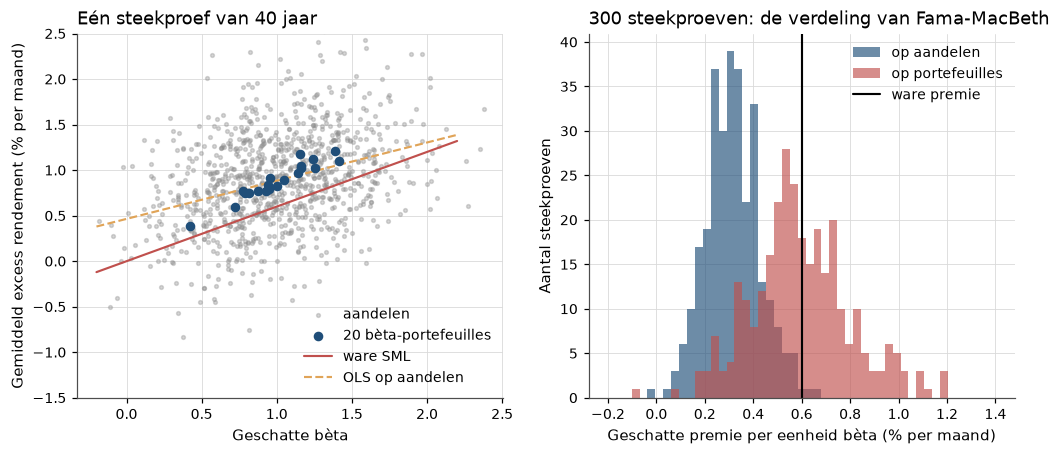

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
mean_stock, b_stock, mean_port, b_port = example
grid = np.linspace(-0.2, 2.2, 50)

ax = axes[0]
ax.scatter(b_stock, 100 * mean_stock, s=6, alpha=0.35, color=hap.plotting.COLORS[7],
           label="aandelen")
ax.scatter(b_port, 100 * mean_port, s=28, zorder=3, color=hap.plotting.COLORS[0],
           label="20 bèta-portefeuilles")
ax.plot(grid, 100 * world.mu_m * grid, color=hap.plotting.COLORS[1], lw=1.4, label="ware SML")
fit = np.polyfit(b_stock, mean_stock, 1)
ax.plot(grid, 100 * np.polyval(fit, grid), color=hap.plotting.COLORS[3], ls="--",
        lw=1.4, label="OLS op aandelen")
ax.set_ylim(-1.5, 2.5)
ax.set_xlabel("Geschatte bèta")
ax.set_ylabel("Gemiddeld excess rendement (% per maand)")
ax.set_title("Eén steekproef van 40 jaar")
ax.legend()

ax = axes[1]
bins = np.linspace(-0.2, 1.4, 50)
ax.hist(100 * sims["g1 aandelen"], bins=bins, alpha=0.65, label="op aandelen")
ax.hist(100 * sims["g1 portefeuilles"], bins=bins, alpha=0.65, label="op portefeuilles")
ax.axvline(100 * world.mu_m, color="black", lw=1.4, label="ware premie")
ax.set_xlabel("Geschatte premie per eenheid bèta (% per maand)")
ax.set_ylabel("Aantal steekproeven")
ax.set_title("300 steekproeven: de verdeling van Fama-MacBeth")
ax.legend()
plt.show()

:::{figure} #cel-capm-simulatie
:label: fig-capm-simulatie
:width: 100%

Links: in één gesimuleerde CAPM-wereld is de lijn door de aandelen te vlak
(gestreept), terwijl de twintig bèta-portefeuilles dicht bij de ware lijn liggen.
Rechts: over 300 steekproeven ligt de verdeling op aandelen links van de ware
premie, die op portefeuilles eromheen. Die laatste blijft breed, want haar
breedte is de standaardfout van het gemiddelde marktrendement.
:::

## Replicatie op echte data

```{admonition} Replicatie
:class: seealso

**Bron.** Black, Jensen en Scholes, *The Capital Asset Pricing Model: Some
Empirical Tests*, 1972 {cite}`BlackJensenScholes1972`, Fama en MacBeth, *Risk,
Return, and Equilibrium: Empirical Tests*, Journal of Political Economy 1973
{cite}`FamaMacBeth1973`, en de GRS-toets {cite}`GibbonsRossShanken1989`.

**Wat.** De tijdreeks- en cross-sectieresultaten van BJS (1931–1965, tien
bèta-portefeuilles en vier subperiodes) en Fama en MacBeth tabel 3, panel A
(1935–6/1968).

**Data hier.** Kenneth French Data Library via `hap.data`. Voor 1931–1965 bouwen we
tien bèta-portefeuilles uit 149 portefeuilles op grootte, boekwaarde/marktwaarde en
industrie; na 1963 gebruiken we French' bèta-decielen en de 25 portefeuilles op
grootte en boekwaarde/marktwaarde (size/BM).

**Verschil met het origineel.** BJS en Fama-MacBeth sorteerden individuele
aandelen en gebruikten een gelijkgewogen index. Onze basisactiva zijn zelf
portefeuilles, deels op grootte gesorteerd, en onze markt is waardegewogen.

**Verwachte afwijking.** Waar de spreiding in bèta groot genoeg is, moet het teken
van de afwijking gelijk zijn aan het origineel: een lijn vlakker dan de premie en
een intercept boven nul, ondubbelzinnig na 1963 en zwakker over 1931–1965. Onze
premie ligt lager, omdat een gelijkgewogen index kleine aandelen zwaarder weegt.
```

De eerste cel bouwt de portefeuilles in de stijl van BJS. Elke december schatten
we per basisactivum een bèta op de voorgaande 60 maanden. We rangschikken de
activa van hoge naar lage bèta, knippen de rangorde in tien even grote groepen
(P1 de hoogste bèta) en houden elke groep een jaar gelijkgewogen vast.

In [8]:
def pre_ranking_betas(history, market_excess):
    """OLS beta of every column of `history` on the market, over the same months."""
    m_dev = market_excess.loc[history.index] - market_excess.loc[history.index].mean()
    return history.sub(history.mean()).mul(m_dev, axis=0).mean() / (m_dev**2).mean()


def beta_sorted_portfolios(assets, market_excess, n_groups=10, window=5, min_obs=48):
    """BJS-style portfolios: sort each December on pre-ranking beta, hold for a year."""
    labels = [f"P{k}" for k in range(1, n_groups + 1)]
    yearly = []
    for year in range(assets.index.year.min() + window - 1, assets.index.year.max()):
        history = assets.loc[f"{year - window + 1}":f"{year}"]
        history = history.loc[:, history.notna().sum() >= min_obs]
        pre_beta = pre_ranking_betas(history, market_excess)
        rank = pre_beta.rank(ascending=False, method="first")    # 1 = highest beta
        group = pd.qcut(rank, n_groups, labels=labels)           # ten equal-size groups
        next_year = assets.loc[f"{year + 1}"]
        returns = {p: next_year[group.index[group == p]].mean(axis=1) for p in labels}
        yearly.append(pd.DataFrame(returns))
    return pd.concat(yearly)

Daarmee ligt de sortering vast. De volgende cel laadt de data en bouwt de drie
verzamelingen testportefeuilles. French' data beginnen in 1926-07, dus de eerste
sortering berust op 54 maanden.

In [9]:
market = hap_data.market_monthly()
rf_month, mkt_excess = market["RF"], market["Mkt-RF"]

base = pd.concat(
    {"sbm": hap_data.french("100_Portfolios_10x10"),
     "ind": hap_data.french("49_Industry_Portfolios")},
    axis=1,
)
base_excess = base.sub(rf_month, axis=0)

bjs = beta_sorted_portfolios(base_excess, mkt_excess)
french_beta = (hap_data.french("Portfolios_Formed_on_BETA")
               .filter(regex="Lo 10|Dec|Hi 10").sub(rf_month, axis=0).dropna())
ff25 = hap_data.french("25_Portfolios_5x5").loc["1963-07":].sub(rf_month, axis=0).dropna()

pd.DataFrame(
    {"portefeuilles": [bjs.shape[1], french_beta.shape[1], ff25.shape[1]],
     "start": [p.index[0].strftime("%Y-%m") for p in (bjs, french_beta, ff25)],
     "eind": [p.index[-1].strftime("%Y-%m") for p in (bjs, french_beta, ff25)]},
    index=["BJS-stijl (eigen constructie)", "French bèta-decielen", "25 size/BM"],
)

,portefeuilles,start,eind
BJS-stijl (eigen constructie),10,1931-01,2026-07
French bèta-decielen,10,1963-07,2026-07
25 size/BM,25,1963-07,2026-07


De tabel toont tien BJS-portefeuilles vanaf 1931, en French' tien bèta-decielen
en 25 size/BM-portefeuilles vanaf 1963-07, het begin van French' reeksen. Eerst de
tijdreeksregressies [](#eq-capm-tijdreeks) per portefeuille over 1931–1965.

In [10]:
def capm_time_series(excess, market_excess):
    """Time-series CAPM regression per portfolio: beta, alpha, mean and its SE."""
    X = sm.add_constant(market_excess.loc[excess.index].rename("markt"))
    rows = {}
    for name, series in excess.items():
        fit = sm.OLS(series, X).fit()
        rows[name] = {
            "bèta": fit.params["markt"],
            "alpha (% p.m.)": 100 * fit.params["const"],
            "t(alpha)": fit.tvalues["const"],
            "gem. excess (% p.m.)": 100 * series.mean(),
            "SE gem. (% p.m.)": 100 * series.std() / np.sqrt(len(series)),
            "R2": fit.rsquared,
        }
    return pd.DataFrame(rows).T


capm_time_series(bjs.loc["1931":"1965"], mkt_excess).round(3)

,bèta,alpha (% p.m.),t(alpha),gem. excess (% p.m.),SE gem. (% p.m.),R2
P1,1.686,0.121,0.470,1.695,0.578,0.808
P2,1.529,0.111,0.517,1.539,0.517,0.830
P3,1.424,0.125,0.738,1.455,0.470,0.873
P4,1.279,0.170,1.358,1.364,0.413,0.911
P5,1.297,0.174,1.280,1.384,0.421,0.899
P6,1.203,0.110,1.060,1.233,0.385,0.929
P7,1.121,0.087,0.808,1.133,0.361,0.914
P8,1.130,0.051,0.537,1.106,0.361,0.933
P9,1.030,-0.044,-0.430,0.917,0.333,0.908
P10,0.909,0.090,1.040,0.939,0.293,0.915


De bèta's lopen van 1,69 naar 0,91, en geen enkele alpha is significant. De
standaardfout van elk gemiddelde is 0,3 tot 0,6% per maand, even groot als de
verschillen tussen de portefeuilles. Over 35 jaar is een gemiddeld rendement dus
slecht meetbaar, net als in de simulatie.

Nu de cross-sectie en GRS. De hoofdsteekproef is die na BJS: daar is de reeks het
langst en de spreiding in bèta het grootst. De functie hieronder schat per steekproef de bèta's over
de hele periode, draait Fama-MacBeth en GRS, en schat de alpha van de portefeuille
met de laagste bèta. Alle rendementen zijn in procenten per maand.

In [11]:
def sml_test(excess, market_excess):
    """Fama-MacBeth with full-period betas, the GRS test, and the alpha of the lowest-beta portfolio."""
    f = market_excess.loc[excess.index]
    betas = excess.apply(lambda col: col.cov(f) / f.var())
    fm = hap.stats.fama_macbeth(excess, {"beta": betas.to_frame().T}, lags=0)
    grs = hap.stats.grs_test(excess, f.to_frame())
    lowest = sm.OLS(excess[betas.idxmin()], sm.add_constant(f)).fit()
    n_assets, n_months = excess.shape[1], len(excess)
    return pd.Series({
        "bèta min": betas.min(), "bèta max": betas.max(),
        "γ0": 100 * fm.loc["const", "estimate"], "t(γ0)": fm.loc["const", "tstat"],
        "γ1": 100 * fm.loc["beta", "estimate"], "t(γ1)": fm.loc["beta", "tstat"],
        "premie": 100 * f.mean(), "SE premie": 100 * f.std() / np.sqrt(n_months),
        "γ1 / premie": fm.loc["beta", "estimate"] / f.mean(),
        "alpha laagste bèta": 100 * lowest.params["const"],
        "t(alpha laagste bèta)": lowest.tvalues["const"],
        "GRS": grs["grs"], "p(GRS)": grs["pvalue"],
        "GRS-grens 5%": stats.f.ppf(0.95, n_assets, n_months - n_assets - 1),
    })

De eerste toepassing is de periode van BJS en Fama en MacBeth. De tabel zet onze
getallen naast de gepubliceerde. Let op de kolommen $\gamma_1$: het CAPM voorspelt
een helling gelijk aan de premie.

In [12]:
samples = {
    "BJS 1931-1965": (bjs, "1931-01", "1965-12"),
    "  1931-01 - 1939-09": (bjs, "1931-01", "1939-09"),
    "  1939-10 - 1948-06": (bjs, "1939-10", "1948-06"),
    "  1948-07 - 1957-03": (bjs, "1948-07", "1957-03"),
    "  1957-04 - 1965-12": (bjs, "1957-04", "1965-12"),
    "FM 1935-1968": (bjs, "1935-01", "1968-06"),
}
early = pd.DataFrame({label: sml_test(panel.loc[a:b], mkt_excess)
                      for label, (panel, a, b) in samples.items()}).T
comparison = pd.DataFrame({
    "γ0 origineel": [0.359, -0.80, 0.44, 0.78, 1.02, 0.48], "γ0 hier": early["γ0"],
    "t(γ0) hier": early["t(γ0)"],
    "γ1 origineel": [1.08, 3.04, 1.07, 0.33, -0.12, 0.85], "γ1 hier": early["γ1"],
    "premie origineel": [1.42, 2.20, np.nan, np.nan, np.nan, 1.30],
    "premie hier": early["premie"], "SE premie hier": early["SE premie"],
}, index=early.index)
comparison.round(3)

,γ0 origineel,γ0 hier,t(γ0) hier,γ1 origineel,γ1 hier,premie origineel,premie hier,SE premie hier
BJS 1931-1965,0.359,-0.064,-0.193,1.08,1.063,1.42,0.934,0.308
1931-01 - 1939-09,-0.800,-1.820,-1.882,3.04,2.674,2.20,0.843,1.056
1939-10 - 1948-06,0.440,-0.386,-0.643,1.07,1.362,NaN,0.838,0.439
1948-07 - 1957-03,0.780,0.819,2.391,0.33,0.330,NaN,1.245,0.337
1957-04 - 1965-12,1.020,1.792,3.410,-0.12,-0.762,NaN,0.809,0.327
FM 1935-1968,0.480,0.270,0.920,0.85,0.779,1.30,0.956,0.226


Tot en met 1965 is het beeld gemengd: de helling ligt soms boven en soms onder de
premie. Na BJS bekijken we drie verzamelingen: French' reeksen vanaf 1963 en onze
eigen reeks vanaf 1966, het jaar na de steekproef van BJS.

In [13]:
late_samples = {
    "BJS-stijl 1966-heden": bjs.loc["1966-01":],
    "French bèta-decielen 1963-heden": french_beta,
    "25 size/BM 1963-heden": ff25,
}
late = pd.DataFrame({label: sml_test(panel, mkt_excess)
                     for label, panel in late_samples.items()}).T
late[["γ0", "t(γ0)", "γ1", "t(γ1)", "premie", "alpha laagste bèta",
      "t(alpha laagste bèta)", "GRS", "GRS-grens 5%", "p(GRS)"]].round(3)

,γ0,t(γ0),γ1,t(γ1),premie,alpha laagste bèta,t(alpha laagste bèta),GRS,GRS-grens 5%,p(GRS)
BJS-stijl 1966-heden,0.790,3.331,-0.069,-0.236,0.585,0.192,2.684,2.520,1.844,0.006
French bèta-decielen 1963-heden,0.384,1.972,0.276,1.097,0.599,0.207,2.530,2.025,1.843,0.028
25 size/BM 1963-heden,1.164,3.149,-0.370,-0.930,0.599,0.096,1.282,4.196,1.521,0.000


Na BJS is de lijn op alle drie vlakker dan de premie, is geen helling significant
positief, en verwerpt GRS het CAPM op 5%.

**Gedeeltelijk geslaagd.** De tabel meet elke periode aan de verwachte afwijking:
een helling onder de premie en een intercept boven nul (bedragen in % per maand).

| periode | verwacht | hier | oordeel |
|---|---|---|---|
| na BJS (hoofdsteekproef) | vlakker, $\gamma_0 > 0$ | French-decielen $\gamma_1$ 0,28 bij premie 0,60; alpha laagste deciel 0,21 ($t = 2{,}53$); GRS 4,20 > 1,52 | geslaagd |
| 1948–1965 | als BJS | helling daalt, intercept stijgt; 1957–1965 $\gamma_1$ −0,76 (BJS −0,12) | geslaagd |
| 1939–1948 | als BJS | $\gamma_0$ −0,39 (BJS +0,44), lijn steiler dan premie | niet geslaagd |
| 1931–1939, 1931–1965 | zwakker | $\gamma_1$ 1,06 bij premie 0,93 over 1931–1965 | niet geslaagd |
| Fama-MacBeth 1935–1968 | als FM | $\gamma_1$ 0,78 bij premie 0,96; $\gamma_0$ 0,27 (FM 0,48, al excess) | gedeeltelijk |

In de jaren dertig belonen hoge bèta's ruim, ook bij BJS. Bij ons weegt dat zwaarder,
omdat in onze op grootte gesorteerde basisactiva hoge bèta en kleine ondernemingen
dan samenvallen. De premie ligt overal lager dan bij BJS, zoals de verwachte
afwijking voor de waardegewogen index aankondigde.

De figuur zet de twee tijdvakken naast elkaar. Let op de afstand tussen de
doorgetrokken lijn van het CAPM en de gestreepte geschatte lijn.

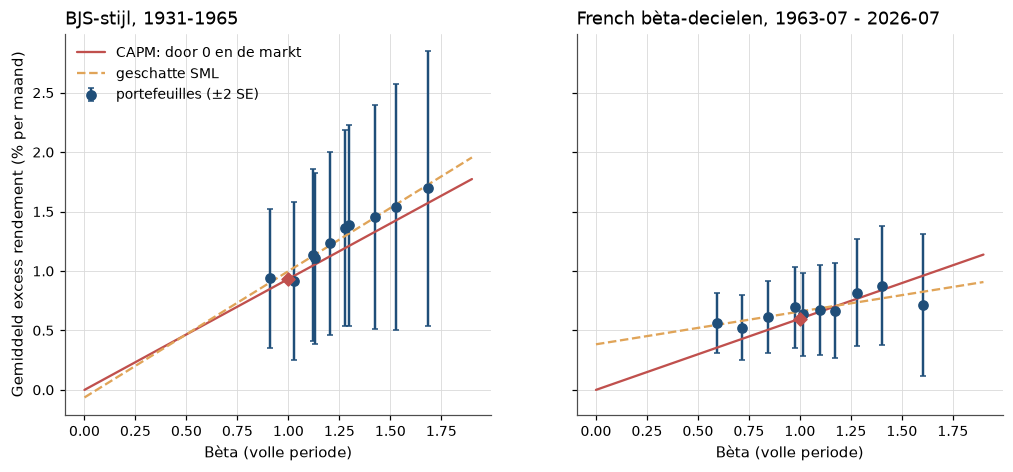

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
panels = [(bjs.loc["1931":"1965"], "BJS-stijl, 1931-1965"),
          (french_beta, f"French bèta-decielen, 1963-07 - {french_beta.index[-1]:%Y-%m}")]
for ax, (panel, title) in zip(axes, panels):
    table = capm_time_series(panel, mkt_excess)
    premium = 100 * mkt_excess.loc[panel.index].mean()
    grid = np.linspace(0, 1.9, 20)
    slope, intercept = np.polyfit(table["bèta"], table["gem. excess (% p.m.)"], 1)
    ax.errorbar(table["bèta"], table["gem. excess (% p.m.)"],
                yerr=2 * table["SE gem. (% p.m.)"], fmt="o", capsize=2,
                color=hap.plotting.COLORS[0], label="portefeuilles ($\\pm$2 SE)")
    ax.plot(grid, premium * grid, color=hap.plotting.COLORS[1], lw=1.5,
            label="CAPM: door 0 en de markt")
    ax.plot(grid, intercept + slope * grid, color=hap.plotting.COLORS[3], ls="--", lw=1.5,
            label="geschatte SML")
    ax.scatter([1.0], [premium], marker="D", zorder=3, color=hap.plotting.COLORS[1])
    ax.set_title(title)
    ax.set_xlabel("Bèta (volle periode)")
axes[0].set_ylabel("Gemiddeld excess rendement (% per maand)")
axes[0].legend(loc="upper left")
plt.show()

:::{figure} #cel-capm-sml-data
:label: fig-capm-sml-data
:width: 100%

Links, 1931–1965 in onze eigen BJS-constructie: de portefeuilles liggen rond de
CAPM-lijn, maar de spreiding in bèta is te klein en de onzekerheid per punt te
groot om veel te onderscheiden. Rechts, French' bèta-decielen na 1963: de
geschatte lijn is ongeveer half zo steil als de CAPM-lijn, met de laagste bèta
erboven en de hoogste eronder.
:::

## Wat er brak, en wat daarna kwam

**Wat het model verklaart.** Het CAPM gaf het vak een taal die het nooit meer
kwijtraakte. Het scheidde risico dat beloond wordt van risico dat niet beloond
wordt, en gaf dat onderscheid een getal: de bèta. Het maakte van de markt de
natuurlijke maatstaf, en van het indexfonds de natuurlijke belegging.
En bèta verklaart veel van de schommelingen: de
$R^2$ van onze BJS-portefeuilles ligt tussen 0,81 en 0,93. Wat bèta niet
verklaart, is het gemiddelde.

**Waar het breekt.** De security market line is te vlak. Op French'
bèta-decielen levert een eenheid bèta sinds 1963 0,28% per maand op, tegen de
0,60% die het CAPM voorspelt. BJS zagen het begin in hun laatste subperiode. Na
hun steekproef is op geen van onze drie verzamelingen een significante beloning
voor bèta over. De simulatie liet zien dat dit op portefeuilles geen artefact van geschatte
bèta's kan zijn.

**Risico of vergissing?** Hier betekent de vraag: is de vlakke lijn een correcte
evenwichtsprijs, of een prijs die ernaast zit? In de risicolezing geldt het
zero-beta-model van {cite:t}`Black1972`. Wie niet kan lenen, betaalt bewust meer
voor hoge bèta, zoals voor elke andere dienst. Wie wel kan lenen, verdient die meerprijs door lage-bèta-aandelen met hefboom te
kopen en hoge-bèta-aandelen short te gaan {cite}`FrazziniPedersen2014`. In de vergissingslezing betalen
beleggers te veel voor hoge bèta omdat ze het rendement overschatten, of omdat
beheerders met een index als maatstaf lage bèta mijden. De prijs is dan fout, en
arbitrageurs corrigeren haar niet omdat hun hefboom beperkt is. Beide lezingen
voorspellen een vlakke lijn, en de data scheiden ze niet.

**Wat er daarna kwam.** Het CAPM werd ook een rekeninstrument: Black en Scholes
gebruikten het in een van hun afleidingen van de prijs van een optie, het
onderwerp van [](#02-09-black-scholes). Dat een CAPM-toets eigenlijk de gekozen
index toetst, werd het punt van [](#03-14-roll).

## Oefeningen

:::{exercise}
:label: ex-capm-1

**Instap: een minder voorzichtige belegger.** Neem het toy-voorbeeld, maar geef
belegger 2 risicoaversie $\theta_2 = 5$ in plaats van 6.

1. Bereken met de hand $\theta_m$, de marktpremie en de premies van A, B en C.
   Veranderen de bèta's?
2. Hoeveel leent belegger 1, en hoeveel leent belegger 2 uit?
3. In welke richting verandert de marktpremie, en waarom?
:::

:::{solution} ex-capm-1
:class: dropdown

**(1)** De vraag in geld is $(150/2 + 750/5)\,\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e}
= 225\,\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e}$, dus $\theta_m = 900/225 = 4$.
De marktpremie is $4 \cdot 28/2025 = 5{,}53\%$. De premies zijn
$4\,\boldsymbol{\Sigma}\mathbf{w}_m = (16;\ 24;\ 4)/225 = (7{,}11\%;\ 10{,}67\%;\ 1{,}78\%)$.
De bèta's hangen alleen van $\boldsymbol{\Sigma}$ en $\mathbf{w}_m$ af en blijven
$9/7$, $27/14$ en $9/28$.

**(2)** $\boldsymbol{\Sigma}^{-1}\boldsymbol{\mu}^{e} = 4\,\mathbf{w}_m$ telt op tot
4. Belegger 1 zet dus $4/2 = 2$ maal zijn vermogen risicovol, 300, en leent 150.
Belegger 2 zet $4/5 = 0{,}8$ maal 750 risicovol, 600, en leent 150 uit.

In [15]:
theta_alt = np.array([2.0, 5.0])
theta_m_alt = supply.sum() / (wealth / theta_alt).sum()
mu_e_alt = theta_m_alt * Sigma @ w_m
risky_share = np.linalg.solve(Sigma, mu_e_alt).sum() / theta_alt
pd.Series(
    {"theta_m": theta_m_alt, "marktpremie": w_m @ mu_e_alt,
     "premie A": mu_e_alt[0], "premie B": mu_e_alt[1], "premie C": mu_e_alt[2],
     "bèta A": (Sigma @ w_m / var_m)[0],
     "risicovrij belegger 1": wealth[0] * (1 - risky_share[0]),
     "risicovrij belegger 2": wealth[1] * (1 - risky_share[1])}
).round(4)

theta_m                    4.0000
marktpremie                0.0553
premie A                   0.0711
premie B                   0.1067
premie C                   0.0178
bèta A                     1.2857
risicovrij belegger 1   -150.0000
risicovrij belegger 2    150.0000
dtype: float64

**(3)** De premie daalt van 6,22% naar 5,53%. De markt als geheel is minder
risicoavers, dus willen beleggers tegen de oude prijzen meer aandelen dan er zijn.
De prijzen stijgen tot de premie laag genoeg is. Wat dit leert: bèta's zijn een
eigenschap van de activa, de premie is een eigenschap van de beleggers.
:::

:::{exercise}
:label: ex-capm-2

**Afleiding: hoe groot is de attenuatie?** Neem de kalibratie van de simulatie.

1. Leid af dat de OLS-bèta uit $T$ maanden, gegeven de marktrendementen $f_t$,
   een meetfout heeft met variantie
   $\sigma^2_\varepsilon/\sum_t (f_t - \bar f)^2 \approx \sigma^2_\varepsilon/(T\sigma_m^2)$.
   Bereken $\kappa$, de verwachte helling en de bias in het intercept uit
   [](#eq-capm-eiv).
2. Hoeveel aandelen $n$ moet een portefeuille minstens bevatten voor
   $\kappa \geq 0{,}95$, bij een spreiding in ware bèta's van 0,30? En bij 0,22,
   de spreiding over portefeuilles in de simulatie?
:::

:::{solution} ex-capm-2
:class: dropdown

**(1)** Met $R^{e}_{i,t} = \beta_i f_t + \varepsilon_{i,t}$ is
$\hat\beta_i - \beta_i = \sum_t (f_t - \bar f)\varepsilon_{i,t} / \sum_t (f_t - \bar f)^2$.
Gegeven de $f_t$ is dat een gewogen som van onafhankelijke $\varepsilon$'s, met de
genoemde variantie; en $\sum_t (f_t - \bar f)^2 \approx T\sigma_m^2$. Dus
$\sigma_u^2 = 0{,}01/(60 \cdot 0{,}002025) = 0{,}0823$ en
$\kappa = 0{,}09/(0{,}09 + 0{,}0823) = 0{,}522$. De verwachte helling is
$0{,}522 \cdot 0{,}6 = 0{,}313\%$ en de intercept-bias
$0{,}478 \cdot 0{,}6 = 0{,}287\%$ per maand.

**(2)** Met meetfoutvariantie $\sigma_u^2/n$ betekent $\kappa \geq 0{,}95$ dat
$n \geq 19\,\sigma_u^2/\sigma_\beta^2$: 18 aandelen bij spreiding 0,30 en 33 bij
spreiding 0,22.

In [16]:
eiv = {}
for label, sd_beta in [("spreiding 0,30", 0.30), ("spreiding 0,22", 0.22)]:
    kappa = sd_beta**2 / (sd_beta**2 + sigma_u2)
    eiv[label] = {
        "sigma_u^2": sigma_u2,
        "kappa (n = 1)": kappa,
        "helling (% p.m.)": 100 * kappa * world.mu_m,
        "intercept-bias (% p.m.)": 100 * (1 - kappa) * world.mu_m,
        "minimale n": int(np.ceil(19 * sigma_u2 / sd_beta**2)),
    }
pd.DataFrame(eiv).T.round(3)

,sigma_u^2,kappa (n = 1),helling (% p.m.),intercept-bias (% p.m.),minimale n
"spreiding 0,30",0.082,0.522,0.313,0.287,18.0
"spreiding 0,22",0.082,0.370,0.222,0.378,33.0


De simulatie gaf 0,316% en 0,298%, dicht bij de formule. Wat dit leert: een paar
dozijn aandelen per portefeuille werkt de meetfout vrijwel weg. De onzekerheid
over de premie zelf krimpt daarna alleen nog met $T$, niet met $n$.
:::

:::{exercise}
:label: ex-capm-3

**Uitbreiding: de keuze van basisactiva.** Herhaal de BJS-replicatie over
1931–1965 en de vier subperiodes met alleen de 49 industrieportefeuilles als
basisactiva (`base_excess["ind"]`).

1. Rapporteer de bèta-spreiding, $\gamma_0$, $\gamma_1$ en $\gamma_1$ gedeeld door
   de marktpremie.
2. Is de lijn over 1931–1965 nu vlakker dan het CAPM voorspelt?
3. Wat leert dit over replicaties waarin de onderzoeker de basisactiva kiest?
:::

:::{solution} ex-capm-3
:class: dropdown

In [17]:
bjs_industries = beta_sorted_portfolios(base_excess["ind"], mkt_excess)
bjs_periods = list(samples.items())[:5]
industries = pd.DataFrame({label: sml_test(bjs_industries.loc[a:b], mkt_excess)
                           for label, (_, a, b) in bjs_periods}).T
industries[["bèta min", "bèta max", "γ0", "t(γ0)", "γ1", "t(γ1)", "premie", "γ1 / premie"]].round(3)

,bèta min,bèta max,γ0,t(γ0),γ1,t(γ1),premie,γ1 / premie
BJS 1931-1965,0.737,1.385,0.291,1.051,0.744,1.852,0.934,0.797
1931-01 - 1939-09,0.735,1.401,-1.141,-1.424,2.046,1.596,0.843,2.427
1939-10 - 1948-06,0.839,1.470,0.311,0.652,0.745,1.177,0.838,0.889
1948-07 - 1957-03,0.527,1.226,0.446,1.683,0.795,1.828,1.245,0.638
1957-04 - 1965-12,0.816,1.242,1.853,3.325,-0.831,-1.345,0.809,-1.028


**(1) en (2)** De laagste bèta daalt van 0,91 naar 0,74, en de lijn over 1931–1965
is nu wél vlakker dan voorspeld: $\gamma_1/\mu_m^{e} = 0{,}80$. Het intercept is
positief, 0,29% per maand, het teken van BJS, al is het met $t = 1{,}05$ niet
significant. In 1931–1939 blijft de lijn te steil.

**(3)** Dezelfde methode op dezelfde maanden geeft een ander antwoord, afhankelijk
van de vraag of de basisactiva op size zijn gesorteerd. Zodra bèta en een ander
kenmerk samenvallen, meet een sortering op bèta beide. Fama en French sorteerden
daarom later eerst op size en daarbinnen op bèta, zie [](#04-18-fama-french). Wat
dit leert: een replicatie toetst ook de keuze van de testactiva.
:::

<!-- Referenties verschijnen automatisch onderaan de pagina. -->